In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

In [70]:
FOLDER = Path.cwd().parent
DATA_RUTE = FOLDER / 'Data'

historico_equipos = pd.read_csv(DATA_RUTE / 'historico_equipos.csv', index_col=[0], parse_dates=[0])
historico_equipos.sort_index(inplace=True)

data_x = pd.read_csv(DATA_RUTE / 'X.csv', index_col=[0], parse_dates=[0])
data_x.sort_index(inplace=True)

# Warning por errores en el formato del csv
data_y = pd.read_csv(DATA_RUTE / 'Y.csv', index_col=[0], parse_dates=[0], dayfirst=True, sep=';', decimal=',')
data_y.sort_index(inplace=True)

# Columnas estan invertidas
data_z = pd.read_csv(DATA_RUTE / 'Z.csv', index_col='Date', parse_dates=['Date'])
data_z.sort_index(inplace=True)


print(historico_equipos.shape, data_x.shape, data_y.shape, data_z.shape)

(3530, 5) (9144, 1) (4485, 1) (3565, 1)


In [71]:
historico_equipos.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3530 entries, 2010-01-04 to 2023-08-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price_X        3530 non-null   float64
 1   Price_Y        3530 non-null   float64
 2   Price_Z        3530 non-null   float64
 3   Price_Equipo1  3530 non-null   float64
 4   Price_Equipo2  3530 non-null   float64
dtypes: float64(5)
memory usage: 165.5 KB


In [72]:
print(historico_equipos.index)

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2023-08-18', '2023-08-21', '2023-08-22', '2023-08-23',
               '2023-08-24', '2023-08-25', '2023-08-28', '2023-08-29',
               '2023-08-30', '2023-08-31'],
              dtype='datetime64[us]', name='Date', length=3530, freq=None)


In [73]:
print(historico_equipos.head(),'\n')
print(historico_equipos.tail())

            Price_X  Price_Y  Price_Z  Price_Equipo1  Price_Equipo2
Date                                                               
2010-01-04    80.12    527.5  2225.25         434.73         931.73
2010-01-05    80.59    527.5  2246.50         449.97         968.56
2010-01-06    81.89    527.5  2302.50         444.48         960.51
2010-01-07    81.51    527.5  2306.50         440.90         960.14
2010-01-08    81.37    552.5  2261.25         448.82         949.55 

            Price_X  Price_Y  Price_Z  Price_Equipo1  Price_Equipo2
Date                                                               
2023-08-25    84.48   554.00  2123.50         450.36         899.65
2023-08-28    84.42   549.00  2116.25         469.03         933.20
2023-08-29    85.49   545.33  2116.25         460.42         901.79
2023-08-30    85.86   543.67  2140.25         464.80         945.40
2023-08-31    86.86   545.00  2165.25         451.73         955.35


In [74]:
print('Datos duplicados', historico_equipos.duplicated().sum(), '\n')

print('----Datos nulos----')
print(historico_equipos.isnull().sum())

Datos duplicados 0 

----Datos nulos----
Price_X          0
Price_Y          0
Price_Z          0
Price_Equipo1    0
Price_Equipo2    0
dtype: int64


In [75]:
historico_equipos.describe().round(2)

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
count,3530.00,3530.00,3530.00,3530.00,3530.00
mean,78.09,555.53,2037.43,460.04,889.98
std,25.19,138.49,373.14,113.68,170.04
min,19.33,257.50,1421.50,208.34,566.00
25%,57.05,482.50,1767.25,398.23,777.70
50%,75.40,541.62,1974.75,451.25,869.78
75%,104.58,620.00,2235.94,515.61,979.12
max,127.98,1062.37,3984.00,855.32,1703.96


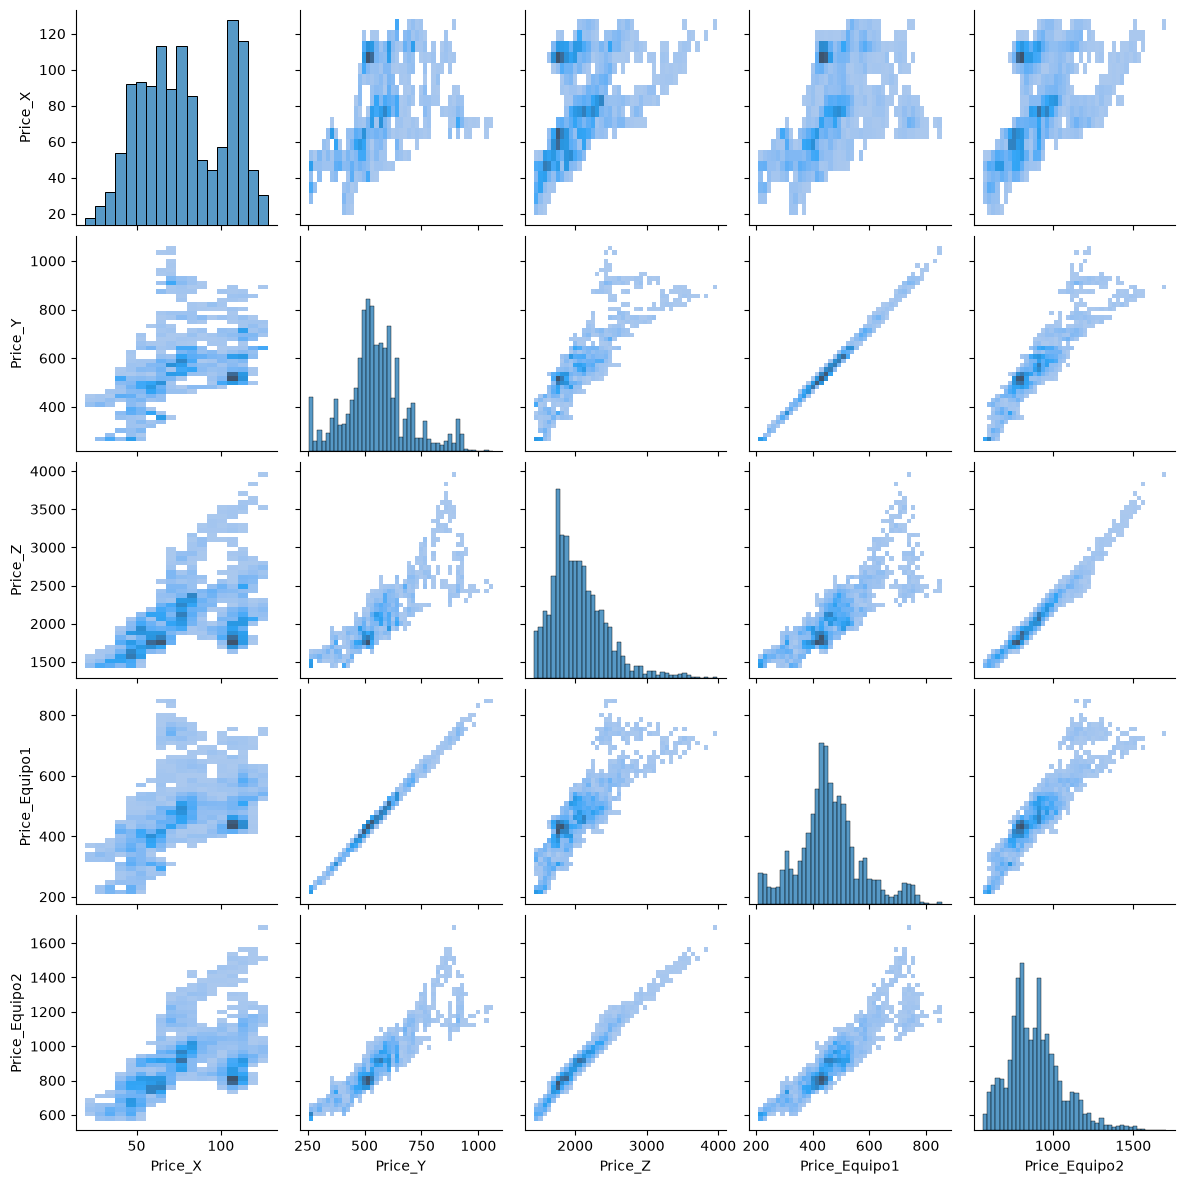

In [76]:
g = sns.pairplot(historico_equipos, kind='hist')
g.figure.set_size_inches(12, 12)

<Axes: title={'center': 'Evolución histórica de precios por variable'}, xlabel='Date'>

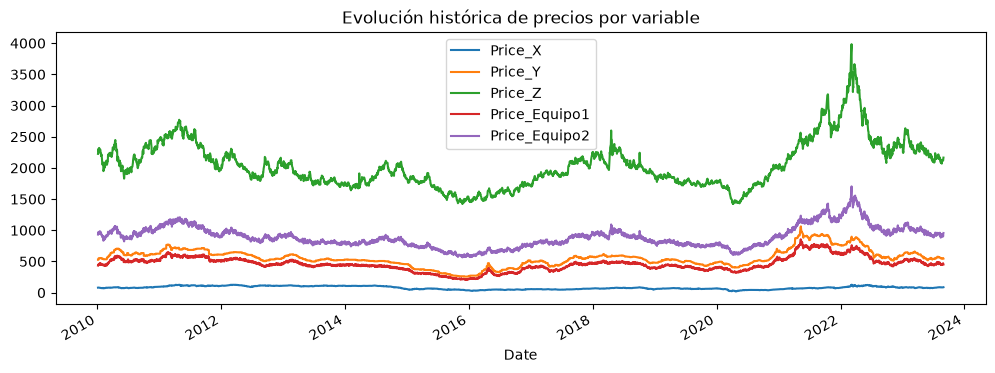

In [77]:
historico_equipos.plot(title='Evolución histórica de precios por variable',figsize=(12, 4))

### conclucion de el data set

- Relaciones entre variables
- distrubucion de las graficas (similitudes)

In [78]:
data_x.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9144 entries, 1988-06-27 to 2024-04-04
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   9144 non-null   float64
dtypes: float64(1)
memory usage: 142.9 KB


In [79]:
print(data_x.head(),'\n')
print(data_x.tail())

            Price
Date             
1988-06-27  15.10
1988-06-28  15.27
1988-06-29  15.47
1988-06-30  14.85
1988-07-01  14.60 

            Price
Date             
2024-03-28  87.48
2024-04-01  87.42
2024-04-02  88.92
2024-04-03  89.35
2024-04-04  89.18


In [80]:
print('Diferencia entre historico_equipos y Price_X:',
      len(data_x.loc['2010-01-01':'2024-12-31']) 
      - len(historico_equipos['Price_X'].loc['2010-01-01':'2024-12-31'])
      )

Diferencia entre historico_equipos y Price_X: 154


In [136]:
data_x_month = data_x.resample('ME').mean()

<Axes: xlabel='Date'>

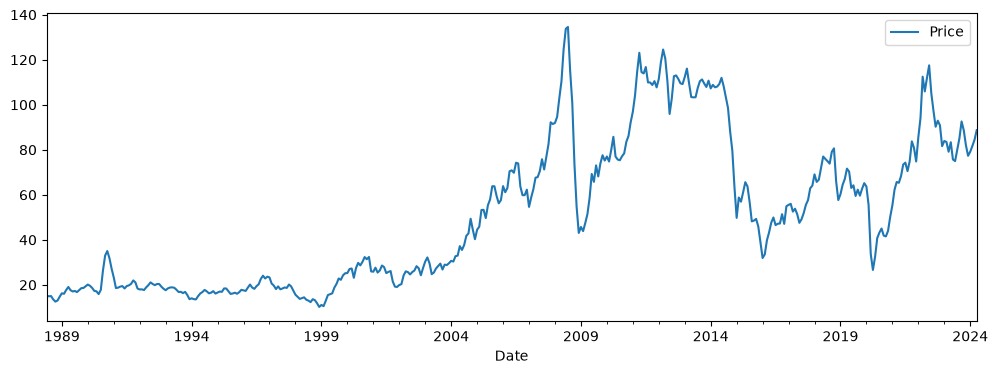

In [141]:
data_x_month.plot(figsize=(12, 4))

<Axes: xlabel='Date'>

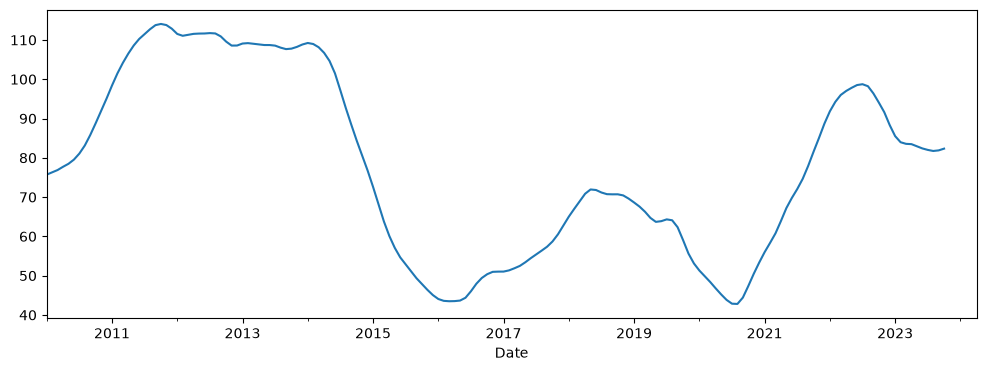

In [142]:
# Movimiento General 
decomposed = seasonal_decompose(data_x_month, period=12)
decomposed.trend['2010-01-01':'2024-12-31'].plot(figsize=(12,4))

<Axes: xlabel='Date'>

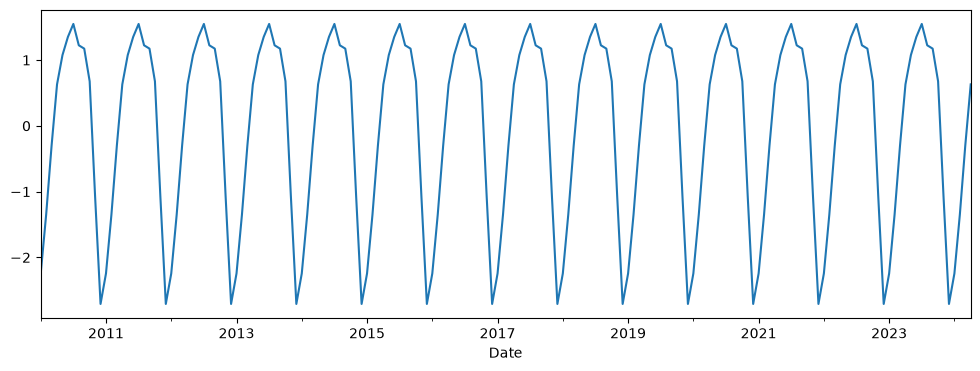

In [143]:
# Comportamiento mensual 
decomposed = seasonal_decompose(data_x_month, period=12)
decomposed.seasonal['2010-01-01':'2024-12-31'].plot(figsize=(12,4))

<Axes: xlabel='Date'>

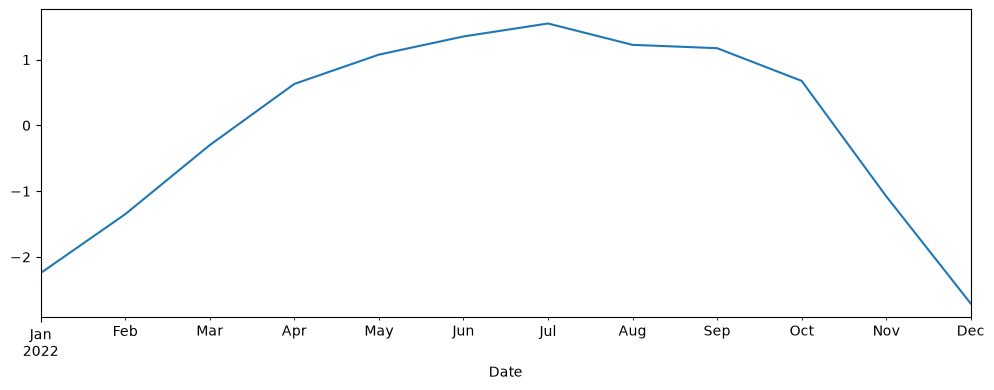

In [144]:
# Comportamiento mensual 
decomposed = seasonal_decompose(data_x_month, period=12)
decomposed.seasonal['2022-01-01':'2022-12-31'].plot(figsize=(12,4))

<Axes: xlabel='Date'>

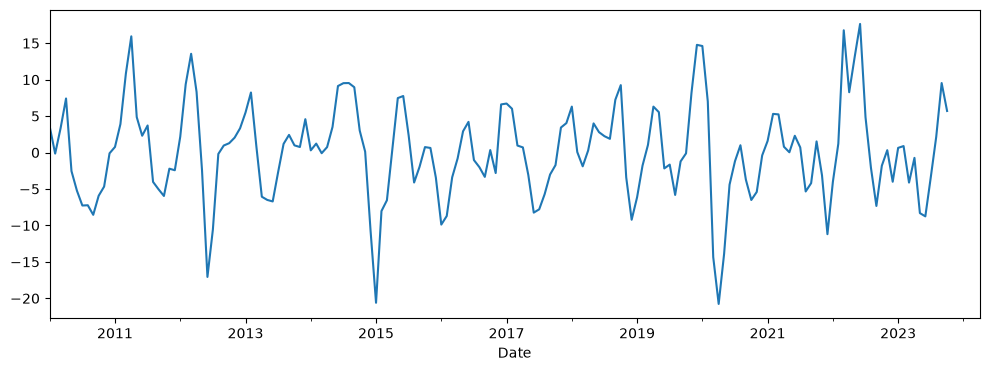

In [145]:
decomposed = seasonal_decompose(data_x_month, period=12)
decomposed.resid['2010-01-01':'2024-12-31'].plot(figsize=(12,4))

In [146]:
data_y.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4485 entries, 2006-07-11 to 2023-09-12
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   4485 non-null   float64
dtypes: float64(1)
memory usage: 199.1 KB


In [147]:
print(data_y.head(),'\n')
print(data_y.tail())

            Price
Date             
2006-07-11  555.0
2006-07-12  555.0
2006-07-13  555.0
2006-07-14  555.0
2006-07-17  555.0 

             Price
Date              
2023-09-06  552.50
2023-09-07  550.00
2023-09-08  545.00
2023-09-11  546.00
2023-09-12  547.33


In [148]:
print('Diferencia entre historico_equipos y Price_Y:', 
      len(data_y.loc['2010-01-01':'2024-12-31']) 
      - len(historico_equipos['Price_Y'].loc['2010-01-01':'2024-12-31'])
      )

Diferencia entre historico_equipos y Price_Y: 46


<Axes: xlabel='Date'>

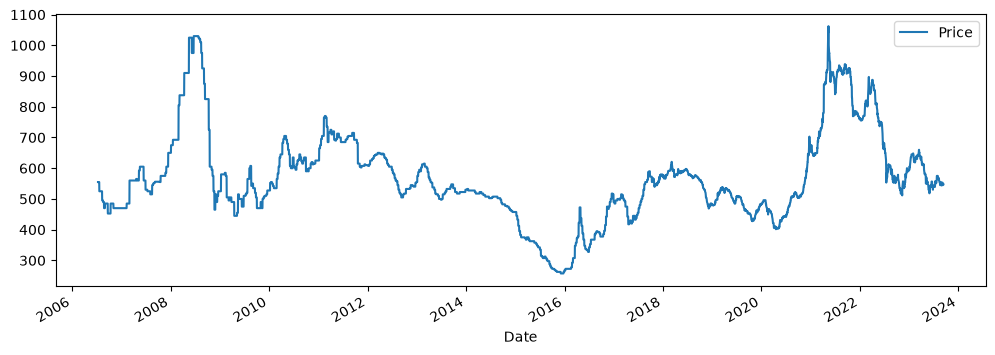

In [149]:
data_y.plot(figsize=(12,4))

In [150]:
data_y_month = data_y.resample('ME').mean()

<Axes: xlabel='Date'>

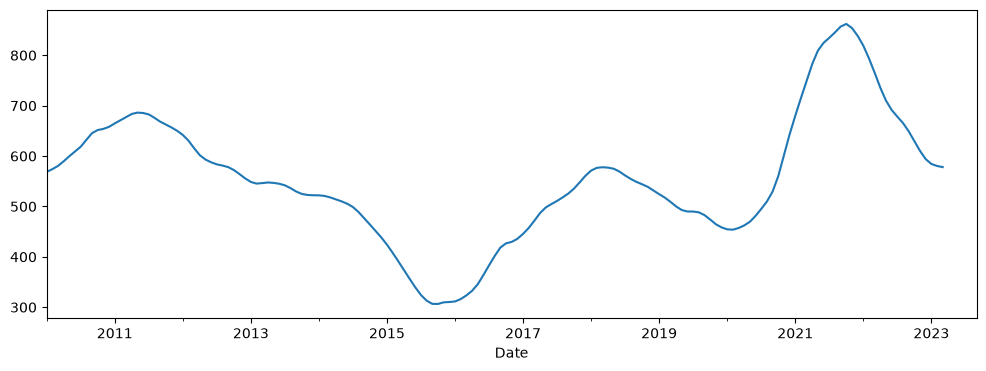

In [151]:
# Movimiento General 
decomposed = seasonal_decompose(data_y_month, period=12)
decomposed.trend['2010-01-01':'2024-12-31'].plot(figsize=(12,4))

<Axes: xlabel='Date'>

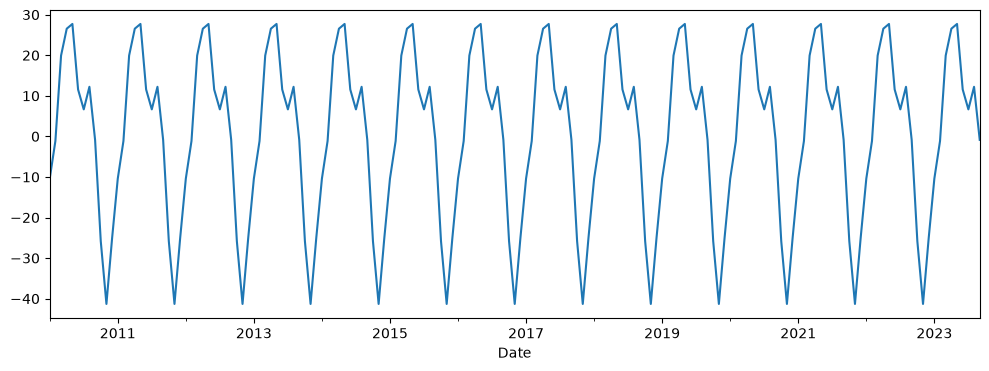

In [152]:
# Comportamiento Anual 2010-2024
decomposed = seasonal_decompose(data_y_month, period=12)
decomposed.seasonal['2010-01-01':'2024-12-31'].plot(figsize=(12,4))

<Axes: xlabel='Date'>

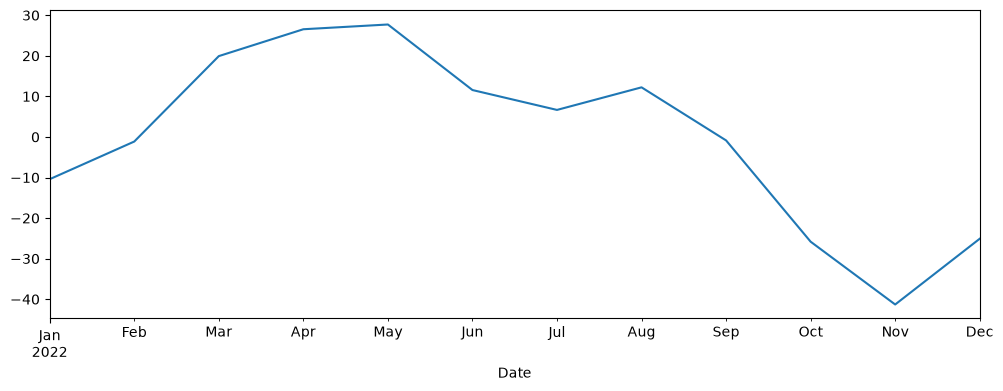

In [153]:
# Comportamiento Anual 2022
decomposed = seasonal_decompose(data_y_month, period=12)
decomposed.seasonal['2022-01-01':'2022-12-31'].plot(figsize=(12,4))

<Axes: xlabel='Date'>

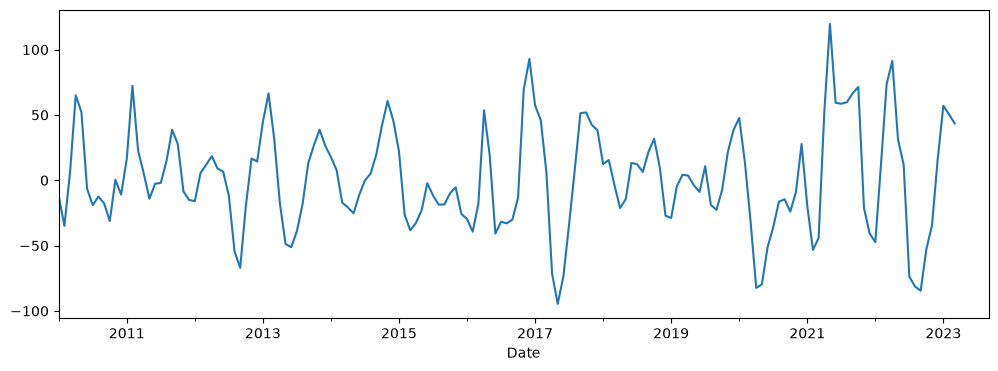

In [154]:
# Comportamiento mensual 
decomposed = seasonal_decompose(data_y_month, period=12)
decomposed.resid['2010-01-01':'2024-12-31'].plot(figsize=(12,4))

In [155]:
data_z.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3565 entries, 2010-01-01 to 2023-08-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   3565 non-null   float64
dtypes: float64(1)
memory usage: 184.7 KB


In [156]:
print(data_z.head(),'\n')
print(data_z.tail())

              Price
Date               
2010-01-01  2225.25
2010-01-04  2225.25
2010-01-05  2246.50
2010-01-06  2302.50
2010-01-07  2306.50 

              Price
Date               
2023-08-25  2123.50
2023-08-28  2116.25
2023-08-29  2116.25
2023-08-30  2140.25
2023-08-31  2165.25


In [157]:
print('Diferencia entre historico_equipos y Price_Z:', 
      len(data_z.loc['2010-01-01':'2024-12-31']) 
      - len(historico_equipos['Price_X'].loc['2010-01-01':'2024-12-31'])
      )

Diferencia entre historico_equipos y Price_Z: 35


<Axes: xlabel='Date'>

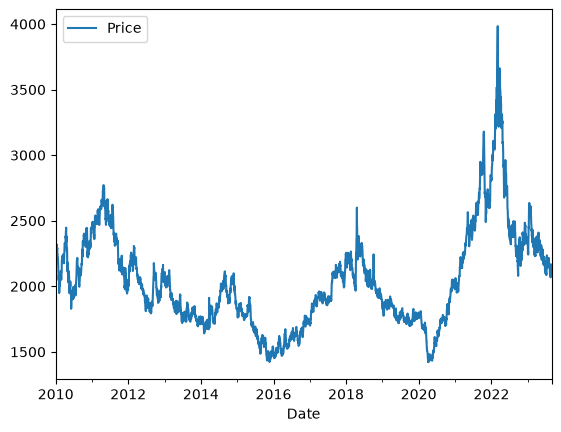

In [158]:
data_z.plot()

In [159]:
data_z_month = data_z.resample('ME').mean()

<Axes: xlabel='Date'>

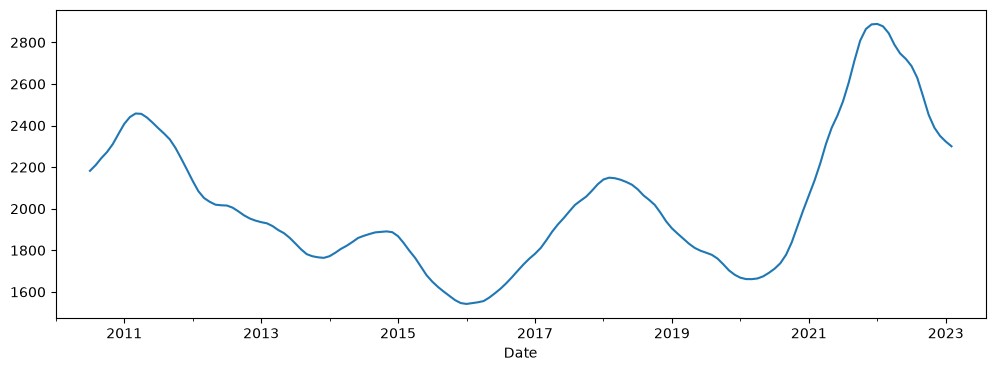

In [160]:
# Movimiento General 
decomposed = seasonal_decompose(data_z_month, period=12)
decomposed.trend['2010-01-01':'2024-12-31'].plot(figsize=(12,4))

<Axes: xlabel='Date'>

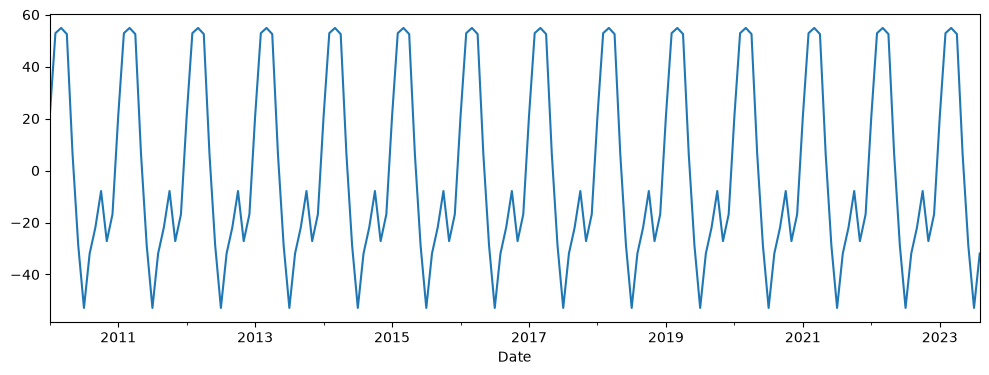

In [161]:
# Comportamiento mensual 
decomposed = seasonal_decompose(data_z_month, period=12)
decomposed.seasonal['2010-01-01':'2024-12-31'].plot(figsize=(12,4))

<Axes: xlabel='Date'>

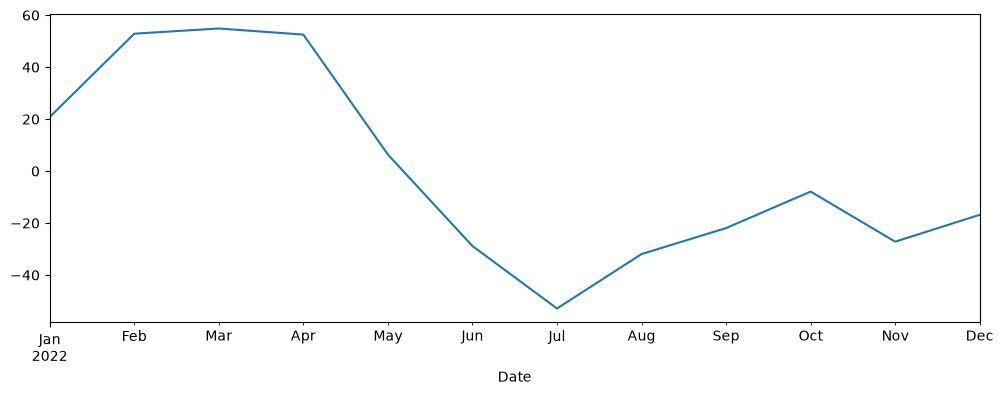

In [162]:
# Comportamiento mensual 
decomposed = seasonal_decompose(data_z_month, period=12)
decomposed.seasonal['2022-01-01':'2022-12-31'].plot(figsize=(12,4))

<Axes: xlabel='Date'>

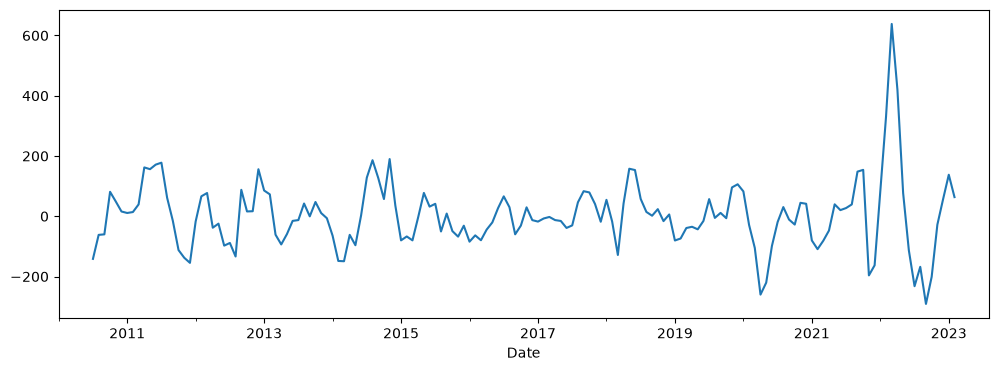

In [163]:
# Comportamiento mensual 
decomposed = seasonal_decompose(data_z_month, period=12)
decomposed.resid['2010-01-01':'2024-12-31'].plot(figsize=(12,4))

Hipotesis parece indicar que una de las razones por que se salen del presupuesto con las materias primas, la compañia que realizan la prosupuestacion a inicios de año y es justo el momento cuando el precio se reduce al resto del año   